<a href="https://colab.research.google.com/github/lhj0954/2026-1_CV/blob/main/HW3_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW: Loss Function, Activation Function, Optimizer 비교 실험

## 실험 목표
본 과제는 손실 함수, 활성화 함수, 최적화 알고리즘이 딥러닝 모델의 학습 결과에 미치는 영향을 실험적으로 비교하고 분석하는 것을 목표로 한다.

## 실험 구성
- 실험 A: CrossEntropy Loss vs MSE Loss
- 실험 B: ReLU vs LeakyReLU vs Sigmoid
- 실험 C: SGD vs SGD+Momentum vs Adam

## 사용 환경
- Google Colab
- Python
- PyTorch
- scikit-learn
- matplotlib
- pandas

In [91]:
# 1. 라이브러리 불러오기

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


In [92]:
# 2. 재현성을 위한 시드 고정

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 가능한 한 같은 결과가 나오도록 설정
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: cpu


In [93]:
# 3. Digits Dataset 준비
# Digits Dataset
# - 8x8 흑백 숫자 이미지
# - 입력 크기: 64
# - 클래스 수: 10개, 0~9

digits = load_digits()

X = digits.data.astype(np.float32)   # shape: (1797, 64)
y = digits.target.astype(np.int64)   # label: 0~9

print("전체 데이터 크기:", X.shape)
print("전체 라벨 크기:", y.shape)
print("클래스 종류:", np.unique(y))

전체 데이터 크기: (1797, 64)
전체 라벨 크기: (1797,)
클래스 종류: [0 1 2 3 4 5 6 7 8 9]


In [94]:
# 4. 데이터 정규화 및 train/test 분리

# 입력 데이터 정규화
# MLP 학습 안정성을 위해 평균 0, 표준편차 1에 가깝게 변환
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test 분리
# stratify=y를 사용하여 각 클래스 비율이 train/test에 비슷하게 유지되도록 함
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# numpy 배열을 PyTorch Tensor로 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Dataset 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 모델 입력/출력 크기
input_size = 64
num_classes = 10

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Input size:", input_size)
print("Number of classes:", num_classes)

Train size: 1437
Test size: 360
Input size: 64
Number of classes: 10


In [95]:
# 5. 공통 MLP 모델 정의
# 실험 A, C에서 사용할 기본 MLP 구조
# 과제 예시 구조(input -> 256 -> 128 -> output)를 따름

class MLP(nn.Module):
    def __init__(self, input_size=64, num_classes=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [96]:
# 6. 평가 함수
# model.eval()과 torch.no_grad()를 사용하여
# 평가 과정에서는 gradient 계산을 하지 않도록 함

def evaluate(model, data_loader, loss_type="ce"):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    ce_loss = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)

            # CrossEntropyLoss
            # logits를 그대로 사용한다.
            # CrossEntropyLoss는 내부적으로 softmax를 포함한다.
            if loss_type == "ce":
                loss = ce_loss(logits, labels)
                preds = torch.argmax(logits, dim=1)

            # MSELoss
            # MSE는 확률값과 one-hot label을 비교해야 하므로
            # softmax를 명시적으로 적용한다.
            elif loss_type == "mse":
                probs = torch.softmax(logits, dim=1)
                labels_onehot = F.one_hot(labels, num_classes=num_classes).float()

                loss = mse_loss(probs, labels_onehot)
                preds = torch.argmax(probs, dim=1)

            else:
                raise ValueError("loss_type은 'ce' 또는 'mse'만 사용할 수 있습니다.")

            total_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [97]:
# 7. 학습 함수
# loss_type만 바꾸면 CrossEntropy와 MSE를 비교할 수 있음
# loss_type = "ce"  : CrossEntropyLoss
# loss_type = "mse" : MSELoss with softmax

def train_loss_experiment(loss_type="ce", epochs=30, lr=0.001):
    set_seed(42)

    model = MLP(input_size=input_size, num_classes=num_classes).to(device)

    # 손실 함수 명시적 설정
    if loss_type == "ce":
        loss_fn = nn.CrossEntropyLoss()
        loss_name = "CrossEntropy"

    elif loss_type == "mse":
        loss_fn = nn.MSELoss()
        loss_name = "MSE with softmax"

    else:
        raise ValueError("loss_type은 'ce' 또는 'mse'만 사용할 수 있습니다.")

    # Optimizer 고정
    # 실험 A에서는 손실 함수만 비교해야 하므로 optimizer는 Adam으로 동일하게 유지
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "grad_norm": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        grad_norm_sum = 0
        batch_count = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(inputs)

            # CrossEntropyLoss 학습
            if loss_type == "ce":
                loss = loss_fn(logits, labels)
                preds = torch.argmax(logits, dim=1)

            # MSELoss 학습
            elif loss_type == "mse":
                probs = torch.softmax(logits, dim=1)
                labels_onehot = F.one_hot(labels, num_classes=num_classes).float()

                loss = loss_fn(probs, labels_onehot)
                preds = torch.argmax(probs, dim=1)

            # 역전파
            loss.backward()

            # Gradient 크기 기록
            # 학습 중 gradient 흐름을 보기 위한 값
            batch_grad_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    batch_grad_norm += p.grad.data.norm(2).item()

            grad_norm_sum += batch_grad_norm
            batch_count += 1

            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            loss_type=loss_type
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["grad_norm"].append(grad_norm_sum / batch_count)

        print(
            f"[{loss_name}] "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | "
            f"Grad Norm: {history['grad_norm'][-1]:.4f}"
        )

    return model, history

In [98]:
# 8. 실험 A 실행
# 동일한 모델 구조, 동일한 optimizer, 동일한 learning rate, 동일한 epoch에서
# 손실 함수만 변경하여 비교

epochs_A = 30
lr_A = 0.001

ce_model, ce_history = train_loss_experiment(
    loss_type="ce",
    epochs=epochs_A,
    lr=lr_A
)

mse_model, mse_history = train_loss_experiment(
    loss_type="mse",
    epochs=epochs_A,
    lr=lr_A
)

[CrossEntropy] Epoch 01/30 | Train Loss: 1.7479 | Train Acc: 0.6500 | Test Loss: 1.0614 | Test Acc: 0.8000 | Grad Norm: 1.5806
[CrossEntropy] Epoch 02/30 | Train Loss: 0.6417 | Train Acc: 0.8720 | Test Loss: 0.3430 | Test Acc: 0.9139 | Grad Norm: 1.4892
[CrossEntropy] Epoch 03/30 | Train Loss: 0.2441 | Train Acc: 0.9429 | Test Loss: 0.1797 | Test Acc: 0.9472 | Grad Norm: 1.2146
[CrossEntropy] Epoch 04/30 | Train Loss: 0.1271 | Train Acc: 0.9701 | Test Loss: 0.1392 | Test Acc: 0.9694 | Grad Norm: 0.9315
[CrossEntropy] Epoch 05/30 | Train Loss: 0.0790 | Train Acc: 0.9875 | Test Loss: 0.1277 | Test Acc: 0.9639 | Grad Norm: 0.7528
[CrossEntropy] Epoch 06/30 | Train Loss: 0.0553 | Train Acc: 0.9930 | Test Loss: 0.1155 | Test Acc: 0.9722 | Grad Norm: 0.6119
[CrossEntropy] Epoch 07/30 | Train Loss: 0.0413 | Train Acc: 0.9958 | Test Loss: 0.1062 | Test Acc: 0.9694 | Grad Norm: 0.5638
[CrossEntropy] Epoch 08/30 | Train Loss: 0.0292 | Train Acc: 0.9979 | Test Loss: 0.1020 | Test Acc: 0.9750 | Gr

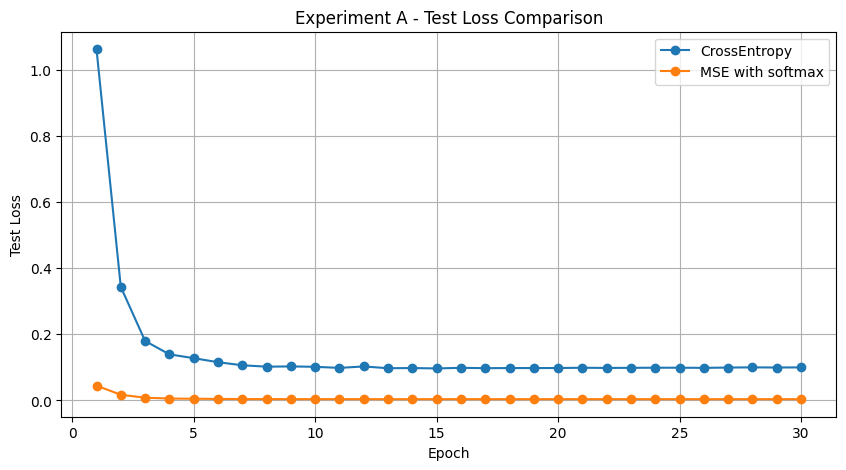

In [99]:
# 9. 실험 A - Loss 그래프

epochs_range = range(1, epochs_A + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, ce_history["test_loss"], marker="o", label="CrossEntropy")
plt.plot(epochs_range, mse_history["test_loss"], marker="o", label="MSE with softmax")

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment A - Test Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

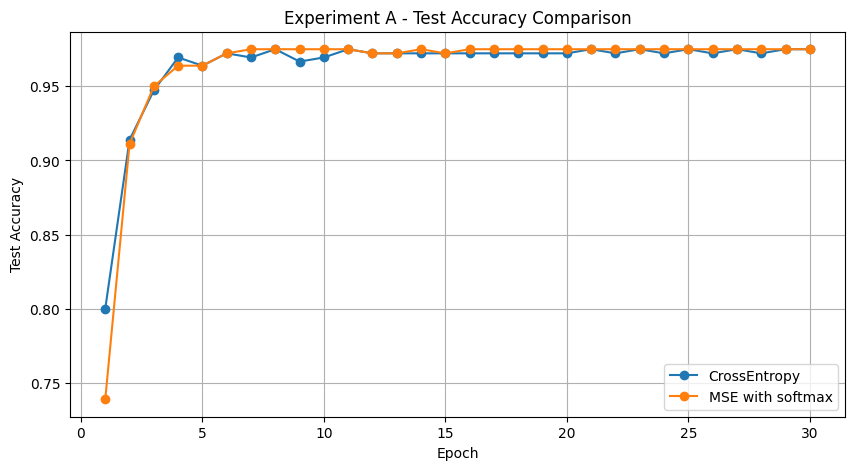

In [100]:
# 10. 실험 A - Accuracy 그래프

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, ce_history["test_acc"], marker="o", label="CrossEntropy")
plt.plot(epochs_range, mse_history["test_acc"], marker="o", label="MSE with softmax")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment A - Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

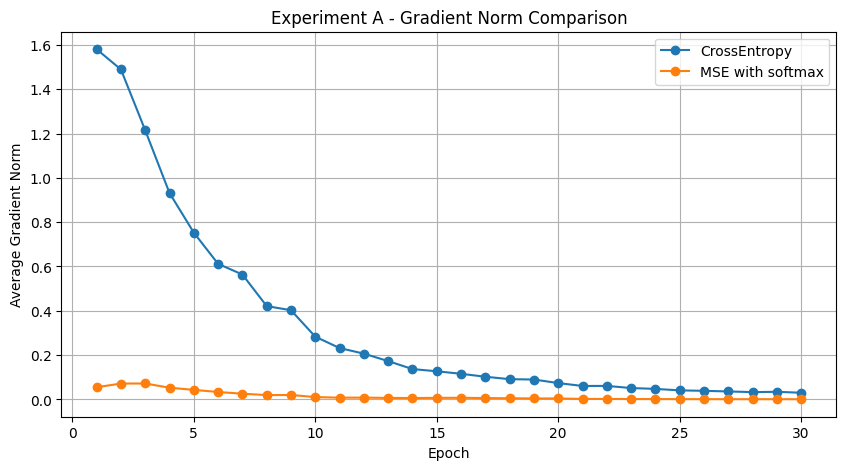

In [101]:
# 11. 실험 A - Gradient Norm 그래프
# Gradient Norm이 작아지는 흐름을 통해
# 학습 초기와 후반의 gradient 변화 양상을 확인한다.

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, ce_history["grad_norm"], marker="o", label="CrossEntropy")
plt.plot(epochs_range, mse_history["grad_norm"], marker="o", label="MSE with softmax")

plt.xlabel("Epoch")
plt.ylabel("Average Gradient Norm")
plt.title("Experiment A - Gradient Norm Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [102]:
# 12. 실험 A - 정량 비교표

def convergence_epoch(acc_list, threshold=0.95):
    """
    accuracy가 특정 threshold 이상에 처음 도달한 epoch를 반환.
    도달하지 못하면 'Not reached' 반환.
    """
    for idx, acc in enumerate(acc_list):
        if acc >= threshold:
            return idx + 1
    return "Not reached"


result_A = pd.DataFrame({
    "Loss Function": [
        "CrossEntropy",
        "MSE with softmax"
    ],
    "Final Test Accuracy": [
        ce_history["test_acc"][-1],
        mse_history["test_acc"][-1]
    ],
    "Minimum Test Loss": [
        min(ce_history["test_loss"]),
        min(mse_history["test_loss"])
    ],
    "Convergence Epoch (Acc >= 0.95)": [
        convergence_epoch(ce_history["test_acc"], threshold=0.95),
        convergence_epoch(mse_history["test_acc"], threshold=0.95)
    ],
    "Final Gradient Norm": [
        ce_history["grad_norm"][-1],
        mse_history["grad_norm"][-1]
    ]
})

result_A

,Loss Function,Final Test Accuracy,Minimum Test Loss,Convergence Epoch (Acc >= 0.95),Final Gradient Norm
0,CrossEntropy,0.975,0.096654,4,0.030228
1,MSE with softmax,0.975,0.003609,3,0.001007


In [103]:
# A-추가 1. 실험 A - 중간 Layer Activation 수집 함수

def get_mlp_activations(model, data_loader):
    model.eval()

    all_a1 = []
    all_a2 = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)

            # 첫 번째 Linear + ReLU
            z1 = model.net[0](inputs)
            a1 = model.net[1](z1)

            # 두 번째 Linear + ReLU
            z2 = model.net[2](a1)
            a2 = model.net[3](z2)

            all_a1.append(a1.detach().cpu().numpy().flatten())
            all_a2.append(a2.detach().cpu().numpy().flatten())

    all_a1 = np.concatenate(all_a1)
    all_a2 = np.concatenate(all_a2)

    return all_a1, all_a2

In [104]:
# A-추가 2. 실험 A - 초반/중반/후반 Activation Snapshot 저장

def train_loss_experiment_with_activation_snapshots(loss_type="ce", epochs=30, lr=0.001):
    set_seed(42)

    model = MLP(input_size=input_size, num_classes=num_classes).to(device)

    if loss_type == "ce":
        loss_fn = nn.CrossEntropyLoss()
        loss_name = "CrossEntropy"
    elif loss_type == "mse":
        loss_fn = nn.MSELoss()
        loss_name = "MSE with softmax"
    else:
        raise ValueError("loss_type은 'ce' 또는 'mse'만 가능합니다.")

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 초반, 중반, 후반 epoch
    snapshot_epochs = [1, epochs // 2, epochs]
    snapshots = {}

    for epoch in range(epochs):
        model.train()

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(inputs)

            if loss_type == "ce":
                loss = loss_fn(logits, labels)

            elif loss_type == "mse":
                probs = torch.softmax(logits, dim=1)
                labels_onehot = F.one_hot(labels, num_classes=num_classes).float()
                loss = loss_fn(probs, labels_onehot)

            loss.backward()
            optimizer.step()

        # 해당 epoch에서 activation 분포 저장
        if (epoch + 1) in snapshot_epochs:
            a1, a2 = get_mlp_activations(model, test_loader)

            snapshots[epoch + 1] = {
                "a1": a1,
                "a2": a2
            }

            print(f"[{loss_name}] Epoch {epoch+1} activation saved")

    return model, snapshots

In [105]:
# A-추가 3. CrossEntropy / MSE Activation Snapshot 실행

ce_snapshot_model, ce_activation_snapshots = train_loss_experiment_with_activation_snapshots(
    loss_type="ce",
    epochs=30,
    lr=0.001
)

mse_snapshot_model, mse_activation_snapshots = train_loss_experiment_with_activation_snapshots(
    loss_type="mse",
    epochs=30,
    lr=0.001
)

[CrossEntropy] Epoch 1 activation saved
[CrossEntropy] Epoch 15 activation saved
[CrossEntropy] Epoch 30 activation saved
[MSE with softmax] Epoch 1 activation saved
[MSE with softmax] Epoch 15 activation saved
[MSE with softmax] Epoch 30 activation saved


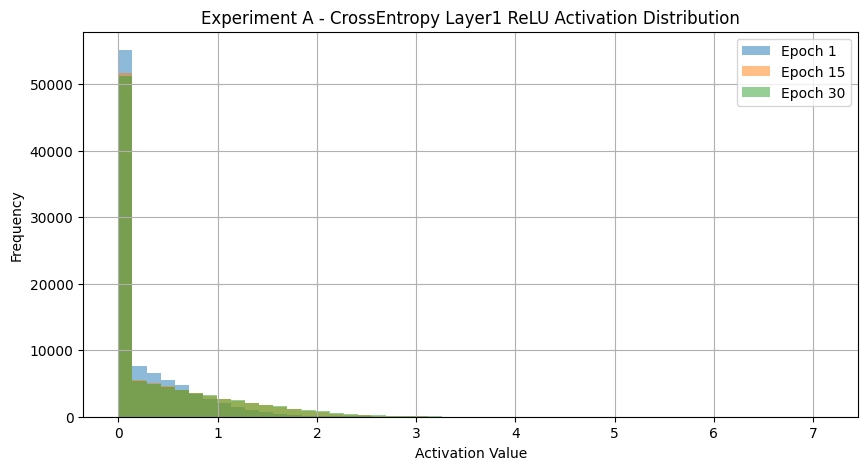

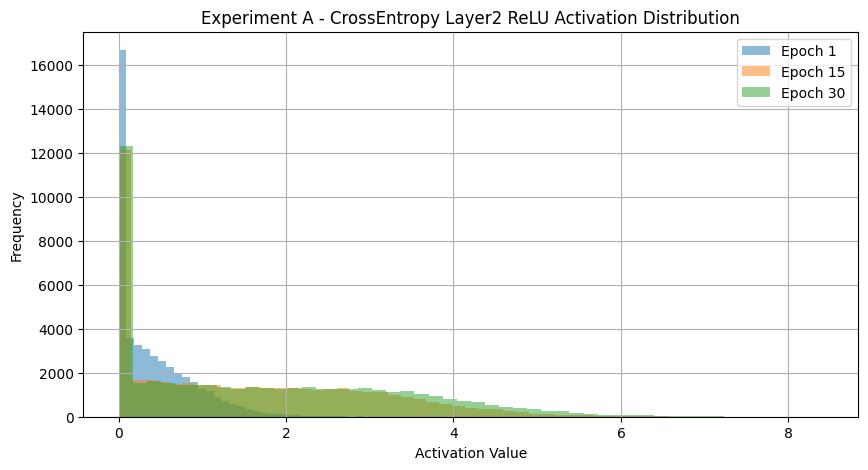

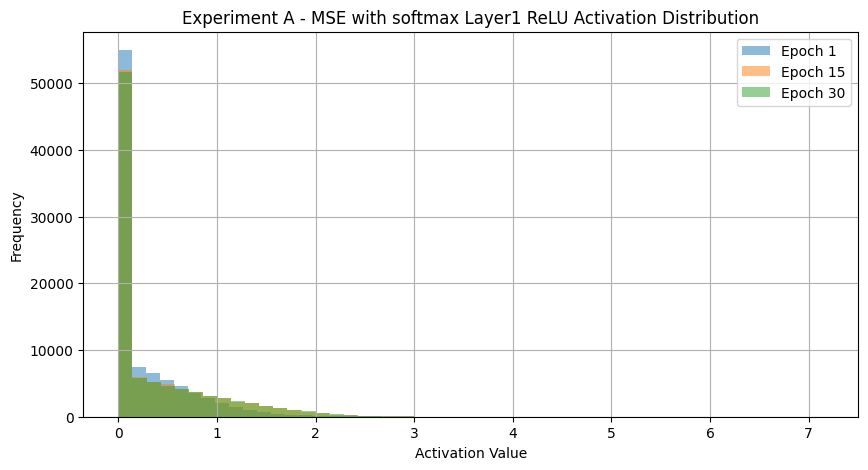

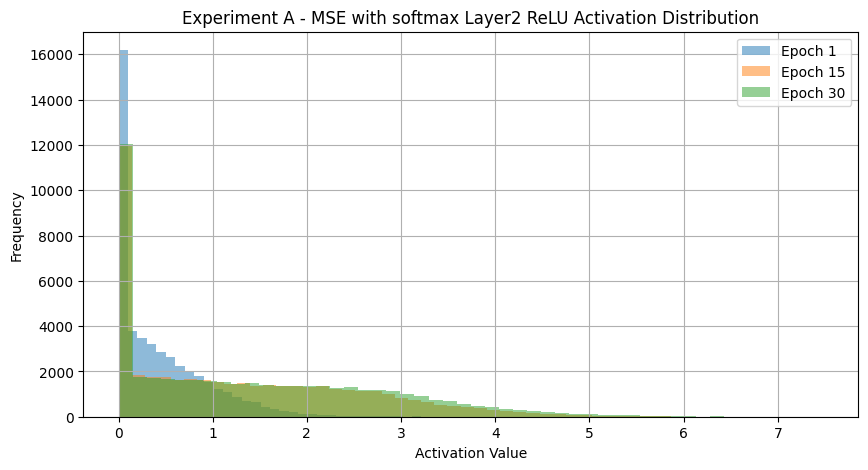

In [106]:
# A-추가 4. 초반/중반/후반 Activation Histogram 시각화

def plot_activation_snapshots_for_A(snapshots, title, layer_name="a1"):
    plt.figure(figsize=(10, 5))

    for epoch, values in snapshots.items():
        plt.hist(
            values[layer_name],
            bins=50,
            alpha=0.5,
            label=f"Epoch {epoch}"
        )

    plt.xlabel("Activation Value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# CrossEntropy - Layer1 / Layer2
plot_activation_snapshots_for_A(
    ce_activation_snapshots,
    "Experiment A - CrossEntropy Layer1 ReLU Activation Distribution",
    layer_name="a1"
)

plot_activation_snapshots_for_A(
    ce_activation_snapshots,
    "Experiment A - CrossEntropy Layer2 ReLU Activation Distribution",
    layer_name="a2"
)

# MSE with softmax - Layer1 / Layer2
plot_activation_snapshots_for_A(
    mse_activation_snapshots,
    "Experiment A - MSE with softmax Layer1 ReLU Activation Distribution",
    layer_name="a1"
)

plot_activation_snapshots_for_A(
    mse_activation_snapshots,
    "Experiment A - MSE with softmax Layer2 ReLU Activation Distribution",
    layer_name="a2"
)

In [107]:
# 14. 실험 B - make_moons 데이터셋 준비
# make_moons는 2차원 비선형 분류 문제이므로
# 활성화 함수에 따른 결정 경계와 학습 차이를 보기 좋다.

from sklearn.datasets import make_moons

set_seed(42)

X_b, y_b = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42
)

X_b = X_b.astype(np.float32)
y_b = y_b.astype(np.int64)

# 정규화
scaler_b = StandardScaler()
X_b_scaled = scaler_b.fit_transform(X_b)

# train/test 분리
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b_scaled,
    y_b,
    test_size=0.2,
    random_state=42,
    stratify=y_b
)

# Tensor 변환
X_b_train_tensor = torch.tensor(X_b_train, dtype=torch.float32)
y_b_train_tensor = torch.tensor(y_b_train, dtype=torch.long)

X_b_test_tensor = torch.tensor(X_b_test, dtype=torch.float32)
y_b_test_tensor = torch.tensor(y_b_test, dtype=torch.long)

# Dataset / DataLoader
train_dataset_b = TensorDataset(X_b_train_tensor, y_b_train_tensor)
test_dataset_b = TensorDataset(X_b_test_tensor, y_b_test_tensor)

train_loader_b = DataLoader(train_dataset_b, batch_size=64, shuffle=True)
test_loader_b = DataLoader(test_dataset_b, batch_size=128, shuffle=False)

input_size_b = 2
num_classes_b = 2

print("Experiment B Train size:", len(train_dataset_b))
print("Experiment B Test size:", len(test_dataset_b))
print("Input size:", input_size_b)
print("Number of classes:", num_classes_b)

Experiment B Train size: 800
Experiment B Test size: 200
Input size: 2
Number of classes: 2


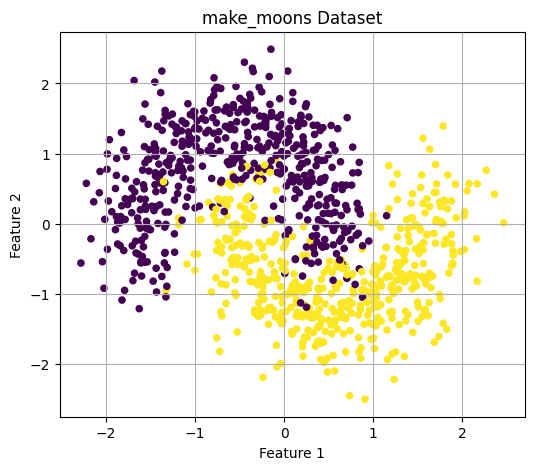

In [108]:
# 15. make_moons 데이터 시각화

plt.figure(figsize=(6, 5))
plt.scatter(X_b_scaled[:, 0], X_b_scaled[:, 1], c=y_b, s=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("make_moons Dataset")
plt.grid(True)
plt.show()

In [109]:
# 16. 실험 B - 활성화 함수 비교용 MLP
# activation_type만 바꾸면
# ReLU, LeakyReLU, Sigmoid를 비교할 수 있다.

class ActivationMLP(nn.Module):
    def __init__(self, activation_type="relu"):
        super().__init__()

        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

        if activation_type == "relu":
            self.activation1 = nn.ReLU()
            self.activation2 = nn.ReLU()

        elif activation_type == "leaky_relu":
            self.activation1 = nn.LeakyReLU(negative_slope=0.01)
            self.activation2 = nn.LeakyReLU(negative_slope=0.01)

        elif activation_type == "sigmoid":
            self.activation1 = nn.Sigmoid()
            self.activation2 = nn.Sigmoid()

        else:
            raise ValueError("activation_type은 'relu', 'leaky_relu', 'sigmoid'만 가능합니다.")

        self.activation_type = activation_type

        # Dead ReLU 상황을 보기 위해 작은 표준편차로 초기화
        self.initialize_weights()

    def initialize_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)

            # ReLU 계열에서 음수 방향으로 밀리면 0 출력이 많아질 수 있음
            # Dead ReLU 현상을 관찰하기 위한 설정
            nn.init.constant_(layer.bias, -0.05)

    def forward(self, x, return_activations=False):
        z1 = self.fc1(x)
        a1 = self.activation1(z1)

        z2 = self.fc2(a1)
        a2 = self.activation2(z2)

        logits = self.fc3(a2)

        if return_activations:
            return logits, {
                "z1": z1,
                "a1": a1,
                "z2": z2,
                "a2": a2
            }

        return logits

In [110]:
# 17. 실험 B - 평가 함수
# 과제 조건에 맞게 model.eval(), torch.no_grad() 사용

def evaluate_activation_model(model, data_loader):
    model.eval()

    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = loss_fn(logits, labels)

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [111]:
# 18. Dead ReLU 비율 및 Gradient Norm 계산 함수

def calculate_dead_ratio(activations):
    """
    activation 값이 0에 가까운 비율을 계산한다.
    ReLU에서는 이 값이 Dead ReLU 비율로 해석 가능하다.
    LeakyReLU는 음수에서도 작은 기울기를 가지므로 완전한 dead 상태가 줄어든다.
    """
    dead_info = {}

    for layer_name in ["a1", "a2"]:
        act = activations[layer_name].detach()

        dead_ratio = (act.abs() < 1e-8).float().mean().item()
        dead_info[layer_name] = dead_ratio

    return dead_info


def calculate_layer_grad_norm(model):
    """
    각 layer의 gradient norm을 계산한다.
    gradient가 너무 작으면 gradient vanishing 가능성을 볼 수 있다.
    """
    grad_info = {}

    for name, param in model.named_parameters():
        if param.grad is not None and "weight" in name:
            grad_info[name] = param.grad.data.norm(2).item()

    return grad_info

In [112]:
# 19. Activation 통계 계산 함수
# 각 활성화 함수별로 layer 출력 분포, Dead ReLU 비율, Sigmoid 포화 비율을 확인한다.

def get_activation_stats(model, data_loader):
    model.eval()

    all_a1 = []
    all_a2 = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)

            logits, activations = model(inputs, return_activations=True)

            all_a1.append(activations["a1"].detach().cpu())
            all_a2.append(activations["a2"].detach().cpu())

    a1 = torch.cat(all_a1, dim=0)
    a2 = torch.cat(all_a2, dim=0)

    stats = {
        "a1_mean": a1.mean().item(),
        "a1_std": a1.std().item(),
        "a2_mean": a2.mean().item(),
        "a2_std": a2.std().item(),

        # ReLU에서 0 출력 비율이 높으면 Dead ReLU 가능성
        "dead_ratio_a1": (a1.abs() < 1e-8).float().mean().item(),
        "dead_ratio_a2": (a2.abs() < 1e-8).float().mean().item(),

        # Sigmoid는 0 또는 1 근처로 몰리면 gradient가 작아짐
        "sigmoid_saturation_a1": ((a1 < 0.05) | (a1 > 0.95)).float().mean().item(),
        "sigmoid_saturation_a2": ((a2 < 0.05) | (a2 > 0.95)).float().mean().item()
    }

    return stats

In [113]:
# 20. 실험 B - 활성화 함수 비교 학습 함수
# activation_type만 바꿔서 ReLU, LeakyReLU, Sigmoid를 비교한다.

def train_activation_experiment(activation_type="relu", epochs=300, lr=0.01):
    set_seed(42)

    model = ActivationMLP(activation_type=activation_type).to(device)

    loss_fn = nn.CrossEntropyLoss()

    # 실험 B에서는 optimizer를 Adam으로 고정하고 활성화 함수만 비교
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "grad_fc1": [],
        "grad_fc2": [],
        "grad_fc3": [],
        "dead_ratio_a1": [],
        "dead_ratio_a2": [],
        "sigmoid_saturation_a1": [],
        "sigmoid_saturation_a2": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        grad_fc1_sum = 0
        grad_fc2_sum = 0
        grad_fc3_sum = 0
        batch_count = 0

        for inputs, labels in train_loader_b:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits, activations = model(inputs, return_activations=True)

            loss = loss_fn(logits, labels)
            preds = torch.argmax(logits, dim=1)

            loss.backward()

            # layer별 gradient norm 기록
            grad_fc1_sum += model.fc1.weight.grad.data.norm(2).item()
            grad_fc2_sum += model.fc2.weight.grad.data.norm(2).item()
            grad_fc3_sum += model.fc3.weight.grad.data.norm(2).item()
            batch_count += 1

            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        test_loss, test_acc = evaluate_activation_model(model, test_loader_b)

        act_stats = get_activation_stats(model, test_loader_b)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        history["grad_fc1"].append(grad_fc1_sum / batch_count)
        history["grad_fc2"].append(grad_fc2_sum / batch_count)
        history["grad_fc3"].append(grad_fc3_sum / batch_count)

        history["dead_ratio_a1"].append(act_stats["dead_ratio_a1"])
        history["dead_ratio_a2"].append(act_stats["dead_ratio_a2"])

        history["sigmoid_saturation_a1"].append(act_stats["sigmoid_saturation_a1"])
        history["sigmoid_saturation_a2"].append(act_stats["sigmoid_saturation_a2"])

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(
                f"[{activation_type}] "
                f"Epoch {epoch+1:03d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"Dead a1: {act_stats['dead_ratio_a1']:.3f} | "
                f"Dead a2: {act_stats['dead_ratio_a2']:.3f}"
            )

    return model, history

In [114]:
# 21. 실험 B 실행

epochs_B = 300
lr_B = 0.01

relu_model, relu_history = train_activation_experiment(
    activation_type="relu",
    epochs=epochs_B,
    lr=lr_B
)

leaky_model, leaky_history = train_activation_experiment(
    activation_type="leaky_relu",
    epochs=epochs_B,
    lr=lr_B
)

sigmoid_model, sigmoid_history = train_activation_experiment(
    activation_type="sigmoid",
    epochs=epochs_B,
    lr=lr_B
)

[relu] Epoch 001/300 | Train Loss: 0.6937 | Train Acc: 0.4725 | Test Loss: 0.6932 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[relu] Epoch 050/300 | Train Loss: 0.6933 | Train Acc: 0.5000 | Test Loss: 0.6932 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[relu] Epoch 100/300 | Train Loss: 0.6938 | Train Acc: 0.5000 | Test Loss: 0.6934 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[relu] Epoch 150/300 | Train Loss: 0.6932 | Train Acc: 0.5000 | Test Loss: 0.6932 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[relu] Epoch 200/300 | Train Loss: 0.6933 | Train Acc: 0.4950 | Test Loss: 0.6932 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[relu] Epoch 250/300 | Train Loss: 0.6934 | Train Acc: 0.5000 | Test Loss: 0.6932 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[relu] Epoch 300/300 | Train Loss: 0.6933 | Train Acc: 0.4875 | Test Loss: 0.6932 | Test Acc: 0.5000 | Dead a1: 1.000 | Dead a2: 1.000
[leaky_relu] Epoch 001/300 | Train Loss: 0.6745 | Train

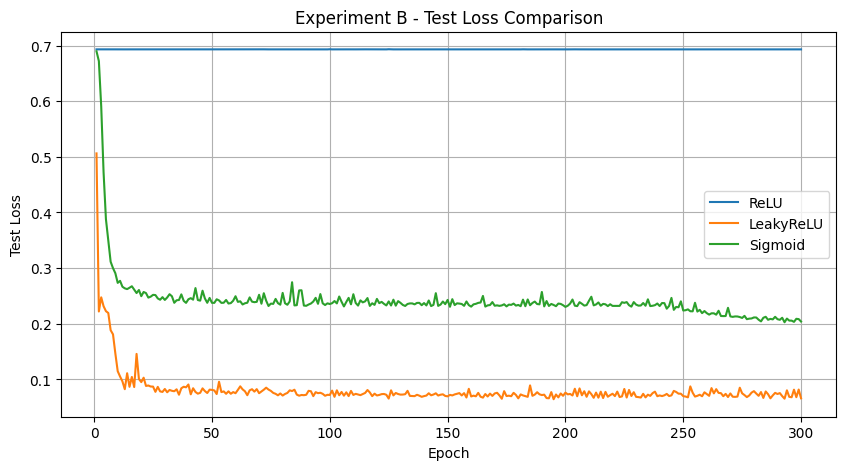

In [115]:
# 22. 실험 B - Loss 그래프

epochs_range_B = range(1, epochs_B + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_B, relu_history["test_loss"], label="ReLU")
plt.plot(epochs_range_B, leaky_history["test_loss"], label="LeakyReLU")
plt.plot(epochs_range_B, sigmoid_history["test_loss"], label="Sigmoid")

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment B - Test Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

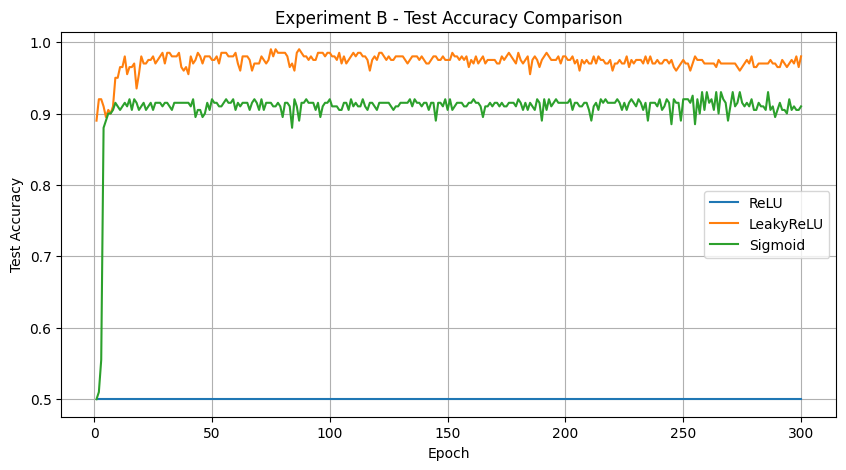

In [116]:
# 23. 실험 B - Accuracy 그래프

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_B, relu_history["test_acc"], label="ReLU")
plt.plot(epochs_range_B, leaky_history["test_acc"], label="LeakyReLU")
plt.plot(epochs_range_B, sigmoid_history["test_acc"], label="Sigmoid")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment B - Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

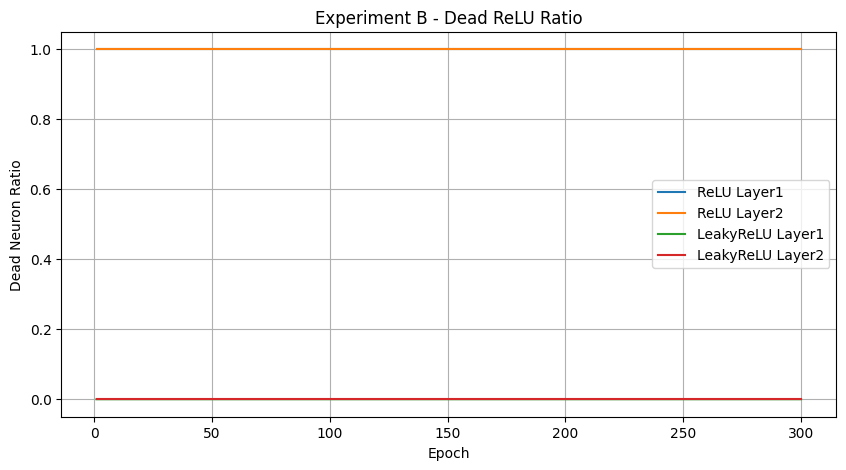

In [117]:
# 24. 실험 B - Dead Neuron 비율 그래프

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_B, relu_history["dead_ratio_a1"], label="ReLU Layer1")
plt.plot(epochs_range_B, relu_history["dead_ratio_a2"], label="ReLU Layer2")
plt.plot(epochs_range_B, leaky_history["dead_ratio_a1"], label="LeakyReLU Layer1")
plt.plot(epochs_range_B, leaky_history["dead_ratio_a2"], label="LeakyReLU Layer2")

plt.xlabel("Epoch")
plt.ylabel("Dead Neuron Ratio")
plt.title("Experiment B - Dead ReLU Ratio")
plt.legend()
plt.grid(True)
plt.show()

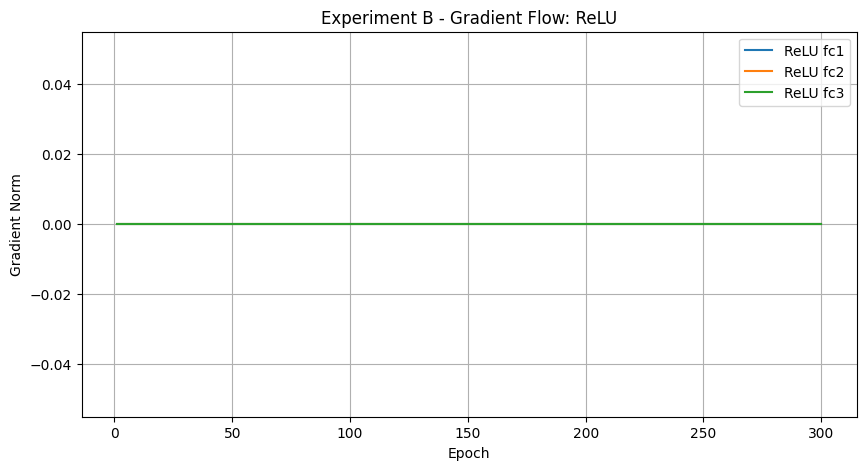

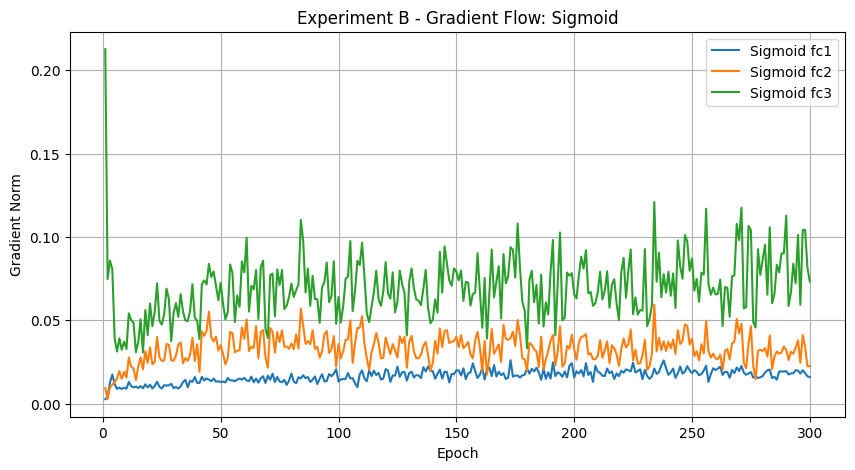

In [118]:
# 25. 실험 B - Gradient Flow 그래프
# 각 layer의 gradient norm을 비교하여 gradient vanishing 여부를 확인한다.

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_B, relu_history["grad_fc1"], label="ReLU fc1")
plt.plot(epochs_range_B, relu_history["grad_fc2"], label="ReLU fc2")
plt.plot(epochs_range_B, relu_history["grad_fc3"], label="ReLU fc3")

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Experiment B - Gradient Flow: ReLU")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_B, sigmoid_history["grad_fc1"], label="Sigmoid fc1")
plt.plot(epochs_range_B, sigmoid_history["grad_fc2"], label="Sigmoid fc2")
plt.plot(epochs_range_B, sigmoid_history["grad_fc3"], label="Sigmoid fc3")

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Experiment B - Gradient Flow: Sigmoid")
plt.legend()
plt.grid(True)
plt.show()

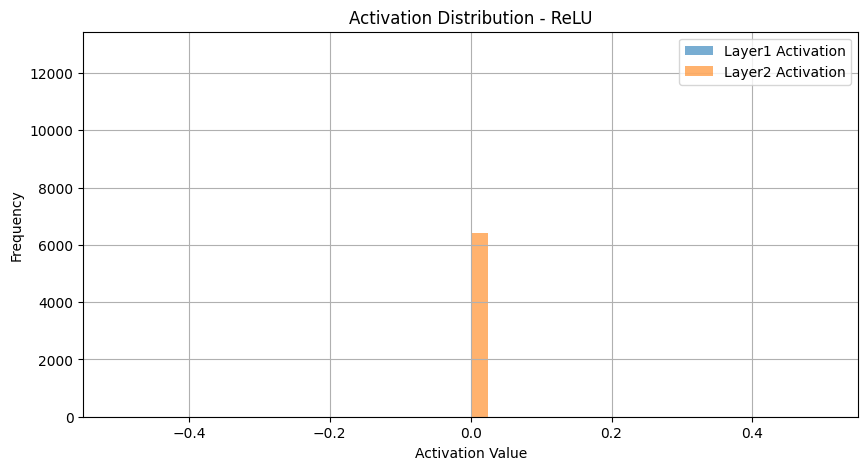

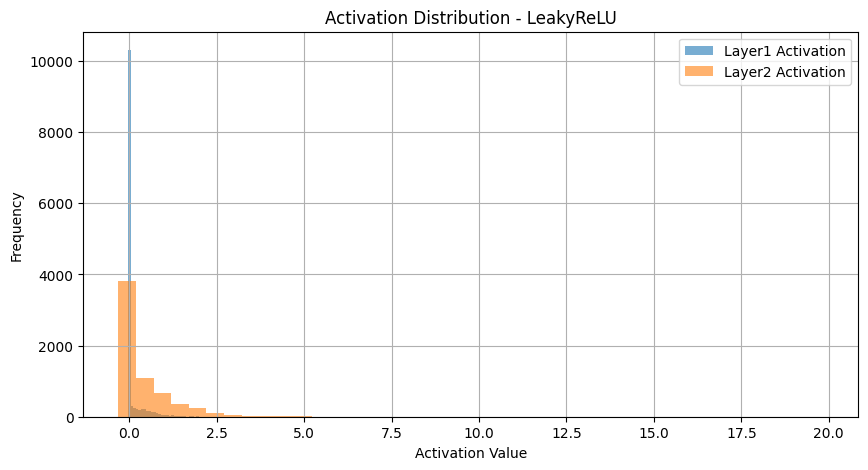

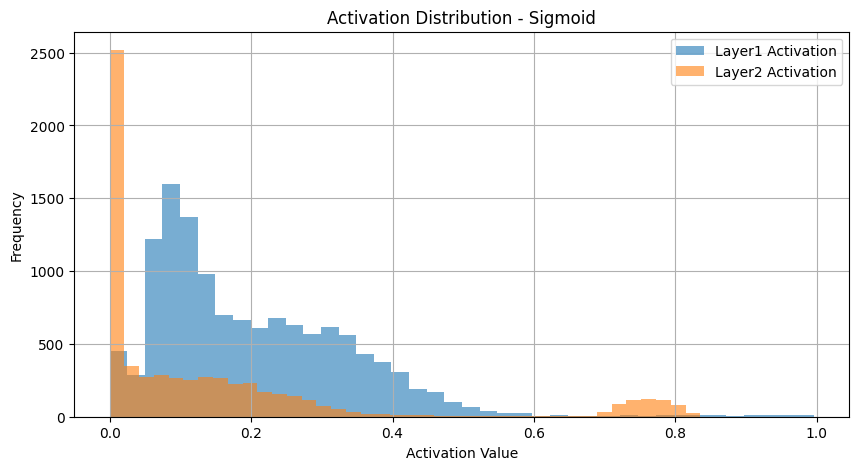

In [119]:
# 26. 실험 B - Activation 분포 히스토그램

def plot_activation_distribution(model, title):
    model.eval()

    all_a1 = []
    all_a2 = []

    with torch.no_grad():
        for inputs, labels in test_loader_b:
            inputs = inputs.to(device)

            logits, activations = model(inputs, return_activations=True)

            all_a1.append(activations["a1"].detach().cpu().numpy().flatten())
            all_a2.append(activations["a2"].detach().cpu().numpy().flatten())

    all_a1 = np.concatenate(all_a1)
    all_a2 = np.concatenate(all_a2)

    plt.figure(figsize=(10, 5))
    plt.hist(all_a1, bins=40, alpha=0.6, label="Layer1 Activation")
    plt.hist(all_a2, bins=40, alpha=0.6, label="Layer2 Activation")
    plt.xlabel("Activation Value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_activation_distribution(relu_model, "Activation Distribution - ReLU")
plot_activation_distribution(leaky_model, "Activation Distribution - LeakyReLU")
plot_activation_distribution(sigmoid_model, "Activation Distribution - Sigmoid")

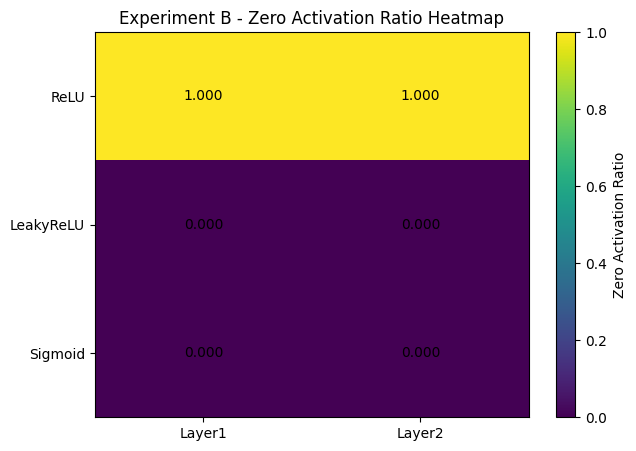

In [120]:
# 27. 실험 B - Dead ReLU 히트맵

dead_heatmap = np.array([
    [relu_history["dead_ratio_a1"][-1], relu_history["dead_ratio_a2"][-1]],
    [leaky_history["dead_ratio_a1"][-1], leaky_history["dead_ratio_a2"][-1]],
    [sigmoid_history["dead_ratio_a1"][-1], sigmoid_history["dead_ratio_a2"][-1]]
])

plt.figure(figsize=(7, 5))
plt.imshow(dead_heatmap, aspect="auto")
plt.colorbar(label="Zero Activation Ratio")

plt.xticks([0, 1], ["Layer1", "Layer2"])
plt.yticks([0, 1, 2], ["ReLU", "LeakyReLU", "Sigmoid"])

plt.title("Experiment B - Zero Activation Ratio Heatmap")

for i in range(dead_heatmap.shape[0]):
    for j in range(dead_heatmap.shape[1]):
        plt.text(j, i, f"{dead_heatmap[i, j]:.3f}", ha="center", va="center")

plt.show()

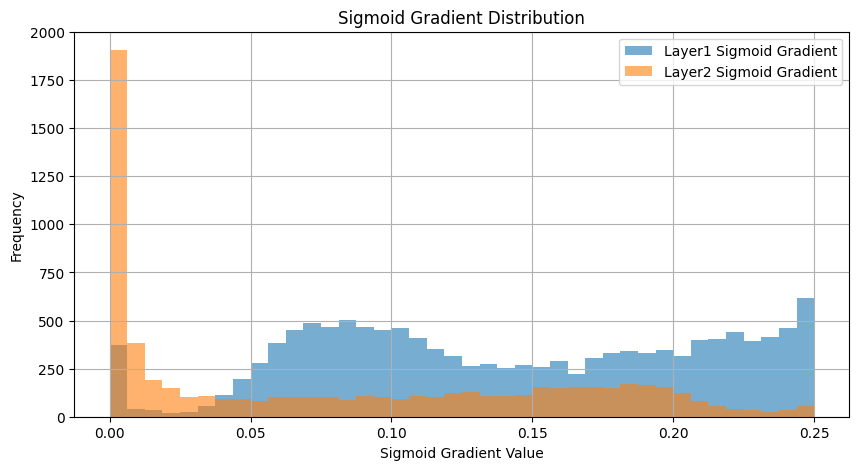

In [121]:
# Sigmoid gradient 분포 시각화

def plot_sigmoid_gradient_distribution(model):
    model.eval()

    all_grad_a1 = []
    all_grad_a2 = []

    with torch.no_grad():
        for inputs, labels in test_loader_b:
            inputs = inputs.to(device)

            logits, activations = model(inputs, return_activations=True)

            a1 = activations["a1"].detach().cpu().numpy().flatten()
            a2 = activations["a2"].detach().cpu().numpy().flatten()

            # sigmoid'(x) = sigmoid(x) * (1 - sigmoid(x))
            grad_a1 = a1 * (1 - a1)
            grad_a2 = a2 * (1 - a2)

            all_grad_a1.append(grad_a1)
            all_grad_a2.append(grad_a2)

    all_grad_a1 = np.concatenate(all_grad_a1)
    all_grad_a2 = np.concatenate(all_grad_a2)

    plt.figure(figsize=(10, 5))
    plt.hist(all_grad_a1, bins=40, alpha=0.6, label="Layer1 Sigmoid Gradient")
    plt.hist(all_grad_a2, bins=40, alpha=0.6, label="Layer2 Sigmoid Gradient")

    plt.xlabel("Sigmoid Gradient Value")
    plt.ylabel("Frequency")
    plt.title("Sigmoid Gradient Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_sigmoid_gradient_distribution(sigmoid_model)

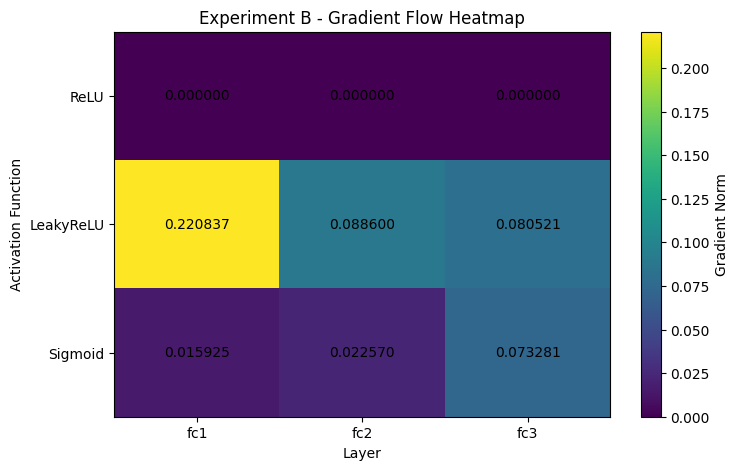

In [122]:
# 실험 B - Gradient Flow Heatmap

gradient_heatmap = np.array([
    [
        relu_history["grad_fc1"][-1],
        relu_history["grad_fc2"][-1],
        relu_history["grad_fc3"][-1]
    ],
    [
        leaky_history["grad_fc1"][-1],
        leaky_history["grad_fc2"][-1],
        leaky_history["grad_fc3"][-1]
    ],
    [
        sigmoid_history["grad_fc1"][-1],
        sigmoid_history["grad_fc2"][-1],
        sigmoid_history["grad_fc3"][-1]
    ]
])

plt.figure(figsize=(8, 5))
plt.imshow(gradient_heatmap, aspect="auto")
plt.colorbar(label="Gradient Norm")

plt.xticks([0, 1, 2], ["fc1", "fc2", "fc3"])
plt.yticks([0, 1, 2], ["ReLU", "LeakyReLU", "Sigmoid"])

plt.title("Experiment B - Gradient Flow Heatmap")

for i in range(gradient_heatmap.shape[0]):
    for j in range(gradient_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{gradient_heatmap[i, j]:.6f}",
            ha="center",
            va="center"
        )

plt.xlabel("Layer")
plt.ylabel("Activation Function")
plt.show()

In [123]:
# 28. 실험 B - 정량 비교표

result_B = pd.DataFrame({
    "Activation Function": [
        "ReLU",
        "LeakyReLU",
        "Sigmoid"
    ],
    "Final Test Accuracy": [
        relu_history["test_acc"][-1],
        leaky_history["test_acc"][-1],
        sigmoid_history["test_acc"][-1]
    ],
    "Minimum Test Loss": [
        min(relu_history["test_loss"]),
        min(leaky_history["test_loss"]),
        min(sigmoid_history["test_loss"])
    ],
    "Final Dead Ratio Layer1": [
        relu_history["dead_ratio_a1"][-1],
        leaky_history["dead_ratio_a1"][-1],
        sigmoid_history["dead_ratio_a1"][-1]
    ],
    "Final Dead Ratio Layer2": [
        relu_history["dead_ratio_a2"][-1],
        leaky_history["dead_ratio_a2"][-1],
        sigmoid_history["dead_ratio_a2"][-1]
    ],
    "Final Grad Norm fc1": [
        relu_history["grad_fc1"][-1],
        leaky_history["grad_fc1"][-1],
        sigmoid_history["grad_fc1"][-1]
    ],
    "Final Grad Norm fc2": [
        relu_history["grad_fc2"][-1],
        leaky_history["grad_fc2"][-1],
        sigmoid_history["grad_fc2"][-1]
    ]
})

result_B

,Activation Function,Final Test Accuracy,Minimum Test Loss,Final Dead Ratio Layer1,Final Dead Ratio Layer2,Final Grad Norm fc1,Final Grad Norm fc2
0,ReLU,0.50,0.693147,0.999844,1.0,0.000000,0.00000
1,LeakyReLU,0.98,0.064352,0.000000,0.0,0.220837,0.08860
2,Sigmoid,0.91,0.202694,0.000078,0.0,0.015925,0.02257


In [124]:
# 30. 실험 C - Optimizer 비교 학습 함수
# 동일한 모델, 동일한 손실함수, 동일한 데이터셋에서
# optimizer와 learning rate만 바꿔 성능을 비교한다.

def train_optimizer_experiment(optimizer_type="sgd", lr=0.01, epochs=30, use_scheduler=True):
    set_seed(42)

    model = MLP(input_size=input_size, num_classes=num_classes).to(device)

    # 손실 함수는 CrossEntropyLoss로 고정
    loss_fn = nn.CrossEntropyLoss()

    # Optimizer 설정
    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
        optimizer_name = "SGD"

    elif optimizer_type == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        optimizer_name = "SGD+Momentum"

    elif optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
        optimizer_name = "Adam"

    else:
        raise ValueError("optimizer_type은 'sgd', 'momentum', 'adam'만 가능합니다.")

    # Exponential Learning Rate Decay 적용
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    else:
        scheduler = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "grad_norm": [],
        "lr": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        grad_norm_sum = 0
        batch_count = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(inputs)
            loss = loss_fn(logits, labels)
            preds = torch.argmax(logits, dim=1)

            loss.backward()

            # Gradient norm 기록
            batch_grad_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    batch_grad_norm += p.grad.data.norm(2).item()

            grad_norm_sum += batch_grad_norm
            batch_count += 1

            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # scheduler는 보통 epoch 끝에서 step
        if scheduler is not None:
            scheduler.step()

        train_loss = total_loss / total
        train_acc = correct / total

        test_loss, test_acc = evaluate(model, test_loader, loss_type="ce")

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["grad_norm"].append(grad_norm_sum / batch_count)
        history["lr"].append(current_lr)

        print(
            f"[{optimizer_name} | lr={lr}] "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | "
            f"Grad Norm: {history['grad_norm'][-1]:.4f} | "
            f"Current LR: {current_lr:.6f}"
        )

    return model, history

In [125]:
# 31. 실험 C 실행

epochs_C = 30
learning_rates = [0.1, 0.01, 0.001]
optimizer_types = ["sgd", "momentum", "adam"]

optimizer_results = {}

for opt_type in optimizer_types:
    for lr in learning_rates:
        key = f"{opt_type}_lr_{lr}"

        print("\n" + "=" * 60)
        print(f"Running Experiment C: optimizer={opt_type}, lr={lr}")
        print("=" * 60)

        model_c, history_c = train_optimizer_experiment(
            optimizer_type=opt_type,
            lr=lr,
            epochs=epochs_C,
            use_scheduler=True
        )

        optimizer_results[key] = {
            "model": model_c,
            "history": history_c
        }


Running Experiment C: optimizer=sgd, lr=0.1
[SGD | lr=0.1] Epoch 01/30 | Train Loss: 2.0741 | Train Acc: 0.5261 | Test Loss: 1.7275 | Test Acc: 0.7083 | Grad Norm: 1.3880 | Current LR: 0.090000
[SGD | lr=0.1] Epoch 02/30 | Train Loss: 1.3449 | Train Acc: 0.7676 | Test Loss: 0.9698 | Test Acc: 0.7944 | Grad Norm: 1.6718 | Current LR: 0.081000
[SGD | lr=0.1] Epoch 03/30 | Train Loss: 0.7590 | Train Acc: 0.8566 | Test Loss: 0.5924 | Test Acc: 0.8611 | Grad Norm: 1.4579 | Current LR: 0.072900
[SGD | lr=0.1] Epoch 04/30 | Train Loss: 0.4958 | Train Acc: 0.9068 | Test Loss: 0.4176 | Test Acc: 0.9139 | Grad Norm: 1.3129 | Current LR: 0.065610
[SGD | lr=0.1] Epoch 05/30 | Train Loss: 0.3598 | Train Acc: 0.9318 | Test Loss: 0.3269 | Test Acc: 0.9250 | Grad Norm: 1.2141 | Current LR: 0.059049
[SGD | lr=0.1] Epoch 06/30 | Train Loss: 0.2806 | Train Acc: 0.9457 | Test Loss: 0.2667 | Test Acc: 0.9389 | Grad Norm: 1.0899 | Current LR: 0.053144
[SGD | lr=0.1] Epoch 07/30 | Train Loss: 0.2312 | Train

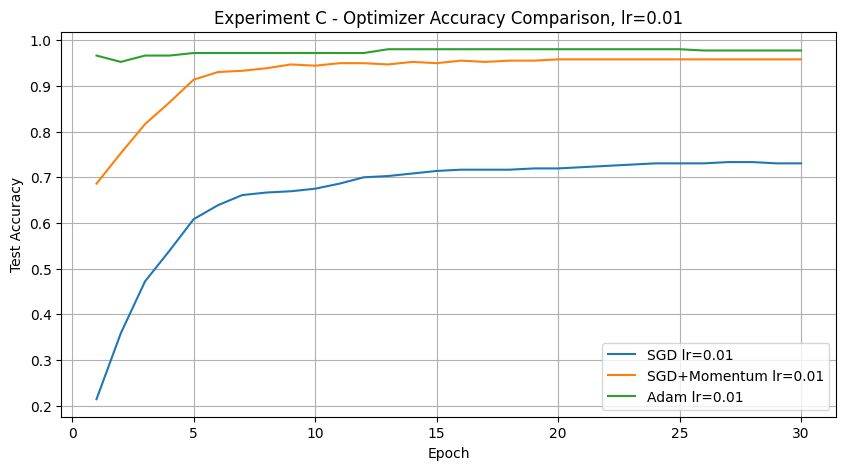

In [126]:
# 32. 실험 C - Optimizer별 Accuracy 비교

epochs_range_C = range(1, epochs_C + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range_C,
    optimizer_results["sgd_lr_0.01"]["history"]["test_acc"],
    label="SGD lr=0.01"
)

plt.plot(
    epochs_range_C,
    optimizer_results["momentum_lr_0.01"]["history"]["test_acc"],
    label="SGD+Momentum lr=0.01"
)

plt.plot(
    epochs_range_C,
    optimizer_results["adam_lr_0.01"]["history"]["test_acc"],
    label="Adam lr=0.01"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment C - Optimizer Accuracy Comparison, lr=0.01")
plt.legend()
plt.grid(True)
plt.show()

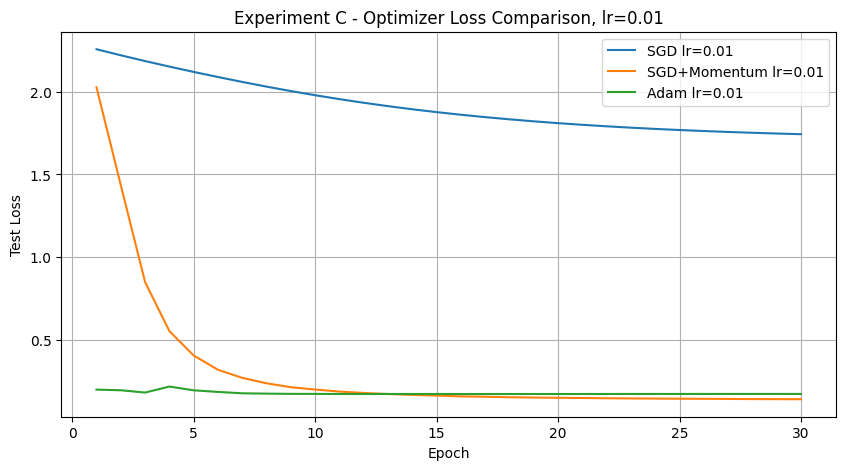

In [127]:
# 33. 실험 C - Optimizer별 Loss 비교

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range_C,
    optimizer_results["sgd_lr_0.01"]["history"]["test_loss"],
    label="SGD lr=0.01"
)

plt.plot(
    epochs_range_C,
    optimizer_results["momentum_lr_0.01"]["history"]["test_loss"],
    label="SGD+Momentum lr=0.01"
)

plt.plot(
    epochs_range_C,
    optimizer_results["adam_lr_0.01"]["history"]["test_loss"],
    label="Adam lr=0.01"
)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment C - Optimizer Loss Comparison, lr=0.01")
plt.legend()
plt.grid(True)
plt.show()

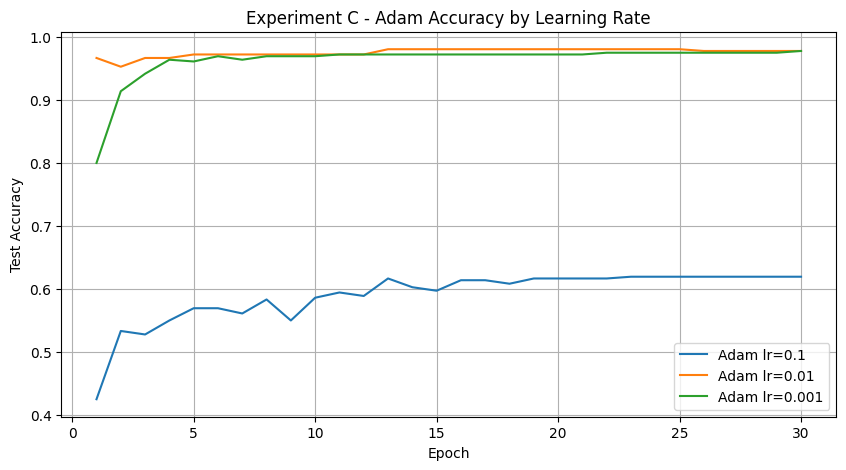

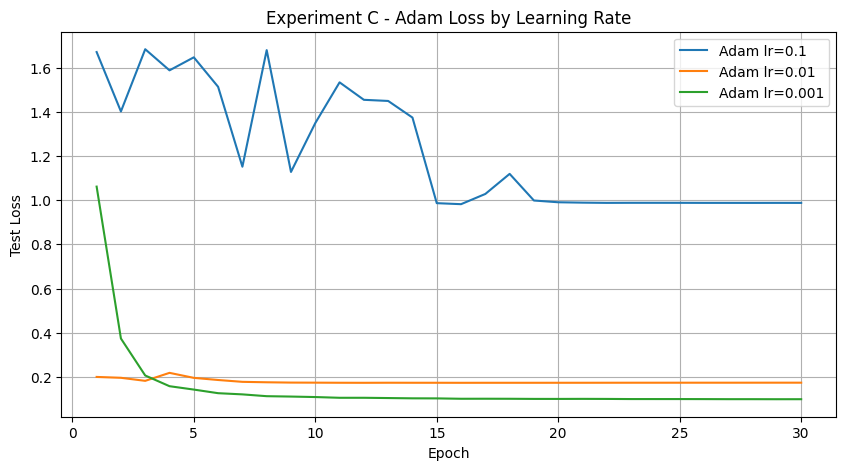

In [128]:
# 34. 실험 C - Adam Learning Rate 비교

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    key = f"adam_lr_{lr}"
    plt.plot(
        epochs_range_C,
        optimizer_results[key]["history"]["test_acc"],
        label=f"Adam lr={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment C - Adam Accuracy by Learning Rate")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))

for lr in learning_rates:
    key = f"adam_lr_{lr}"
    plt.plot(
        epochs_range_C,
        optimizer_results[key]["history"]["test_loss"],
        label=f"Adam lr={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment C - Adam Loss by Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

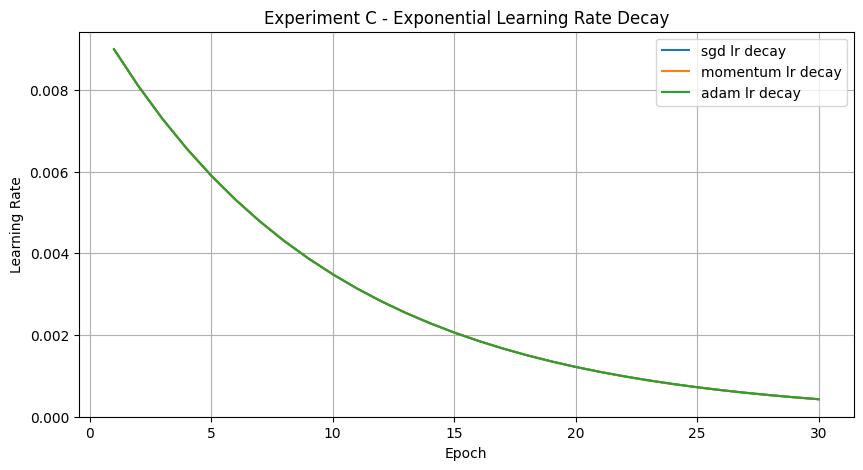

In [129]:
# 35. 실험 C - Exponential Decay 확인

plt.figure(figsize=(10, 5))

for opt_type in optimizer_types:
    key = f"{opt_type}_lr_0.01"
    plt.plot(
        epochs_range_C,
        optimizer_results[key]["history"]["lr"],
        label=f"{opt_type} lr decay"
    )

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Experiment C - Exponential Learning Rate Decay")
plt.legend()
plt.grid(True)
plt.show()

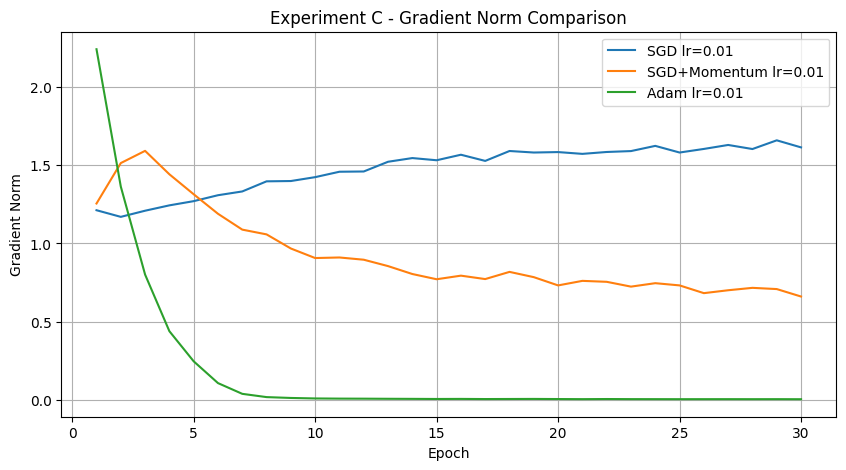

In [130]:
# 36. 실험 C - Gradient Norm 비교

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range_C,
    optimizer_results["sgd_lr_0.01"]["history"]["grad_norm"],
    label="SGD lr=0.01"
)

plt.plot(
    epochs_range_C,
    optimizer_results["momentum_lr_0.01"]["history"]["grad_norm"],
    label="SGD+Momentum lr=0.01"
)

plt.plot(
    epochs_range_C,
    optimizer_results["adam_lr_0.01"]["history"]["grad_norm"],
    label="Adam lr=0.01"
)

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Experiment C - Gradient Norm Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [131]:
# 37. 실험 C - 정량 비교표

def convergence_epoch_c(acc_list, threshold=0.95):
    for idx, acc in enumerate(acc_list):
        if acc >= threshold:
            return idx + 1
    return "Not reached"


rows = []

for opt_type in optimizer_types:
    for lr in learning_rates:
        key = f"{opt_type}_lr_{lr}"
        hist = optimizer_results[key]["history"]

        if opt_type == "sgd":
            opt_name = "SGD"
        elif opt_type == "momentum":
            opt_name = "SGD+Momentum"
        else:
            opt_name = "Adam"

        rows.append({
            "Optimizer": opt_name,
            "Initial Learning Rate": lr,
            "Final Test Accuracy": hist["test_acc"][-1],
            "Minimum Test Loss": min(hist["test_loss"]),
            "Convergence Epoch (Acc >= 0.95)": convergence_epoch_c(hist["test_acc"], threshold=0.95),
            "Final Gradient Norm": hist["grad_norm"][-1],
            "Final Learning Rate": hist["lr"][-1]
        })

result_C = pd.DataFrame(rows)
result_C

,Optimizer,Initial Learning Rate,Final Test Accuracy,Minimum Test Loss,Convergence Epoch (Acc >= 0.95),Final Gradient Norm,Final Learning Rate
0,SGD,0.100,0.963889,0.135010,9,0.625953,0.004239
1,SGD,0.010,0.730556,1.742805,Not reached,1.613397,0.000424
2,SGD,0.001,0.208333,2.257630,Not reached,1.181255,0.000042
3,SGD+Momentum,0.100,0.972222,0.116052,2,0.023836,0.004239
4,SGD+Momentum,0.010,0.958333,0.142283,11,0.660426,0.000424
5,SGD+Momentum,0.001,0.727778,1.789561,Not reached,1.582397,0.000042
6,Adam,0.100,0.619444,0.981894,Not reached,0.071203,0.004239
7,Adam,0.010,0.977778,0.173682,1,0.004272,0.000424
8,Adam,0.001,0.977778,0.099407,4,0.218615,0.000042


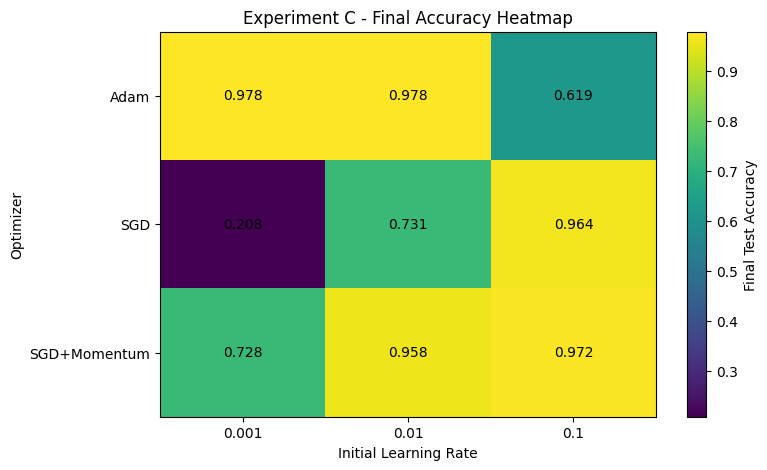

In [132]:
# 38. 실험 C - Optimizer x LR 정확도 히트맵

heatmap_data = result_C.pivot(
    index="Optimizer",
    columns="Initial Learning Rate",
    values="Final Test Accuracy"
)

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data.values, aspect="auto")
plt.colorbar(label="Final Test Accuracy")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.title("Experiment C - Final Accuracy Heatmap")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(
            j,
            i,
            f"{heatmap_data.values[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.xlabel("Initial Learning Rate")
plt.ylabel("Optimizer")
plt.show()

In [139]:
# 실험 C - Activation 수집 함수

# ==============================
# 실험 C - Layer별 Activation 분포 시각화
# 초반 / 중반 / 후반 비교
# ==============================

def visualize_experiment_c_activation(optimizer_type="sgd", lr=0.001, epochs=30):
    set_seed(42)

    model = MLP(input_size=input_size, num_classes=num_classes).to(device)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
        opt_name = "SGD"
    elif optimizer_type == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        opt_name = "SGD+Momentum"
    elif optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
        opt_name = "Adam"

    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    snapshot_epochs = [1, epochs // 2, epochs]
    snapshots = {}

    for epoch in range(epochs):
        model.train()

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(inputs)
            loss = loss_fn(logits, labels)

            loss.backward()
            optimizer.step()

        scheduler.step()

        # 초반 / 중반 / 후반 activation 저장
        if epoch + 1 in snapshot_epochs:
            model.eval()

            layer1_acts = []
            layer2_acts = []

            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(device)

                    z1 = model.net[0](inputs)
                    a1 = model.net[1](z1)

                    z2 = model.net[2](a1)
                    a2 = model.net[3](z2)

                    layer1_acts.append(a1.cpu().numpy().flatten())
                    layer2_acts.append(a2.cpu().numpy().flatten())

            snapshots[epoch + 1] = {
                "Layer1": np.concatenate(layer1_acts),
                "Layer2": np.concatenate(layer2_acts)
            }

    # Layer1 시각화
    plt.figure(figsize=(15, 4))

    for i, epoch in enumerate(snapshot_epochs):
        plt.subplot(1, 3, i + 1)
        plt.hist(snapshots[epoch]["Layer1"], bins=50)
        plt.title(f"{opt_name} lr={lr}\nLayer1 Epoch {epoch}")
        plt.xlabel("Activation Value")
        plt.ylabel("Frequency")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Layer2 시각화
    plt.figure(figsize=(15, 4))

    for i, epoch in enumerate(snapshot_epochs):
        plt.subplot(1, 3, i + 1)
        plt.hist(snapshots[epoch]["Layer2"], bins=50)
        plt.title(f"{opt_name} lr={lr}\nLayer2 Epoch {epoch}")
        plt.xlabel("Activation Value")
        plt.ylabel("Frequency")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    return snapshots

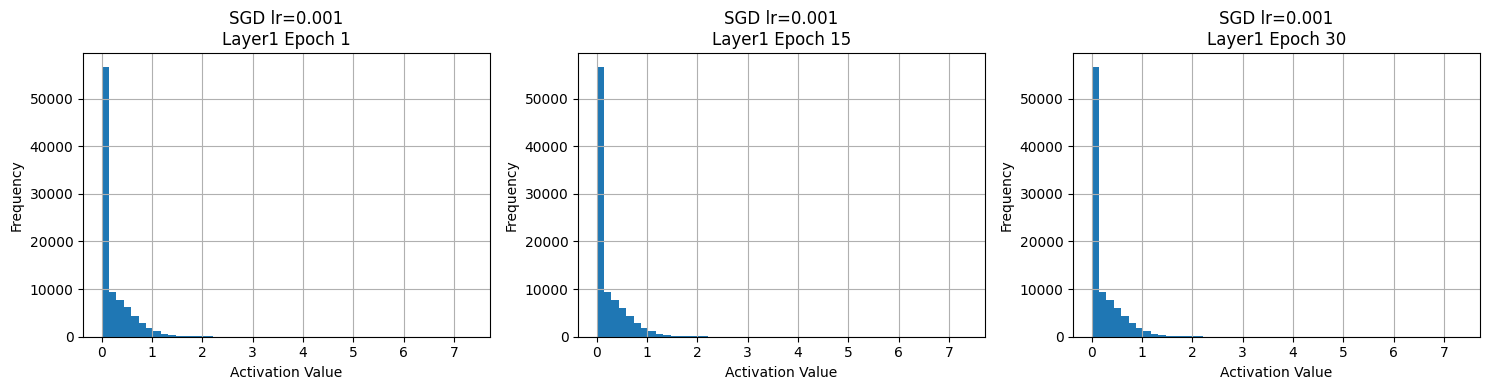

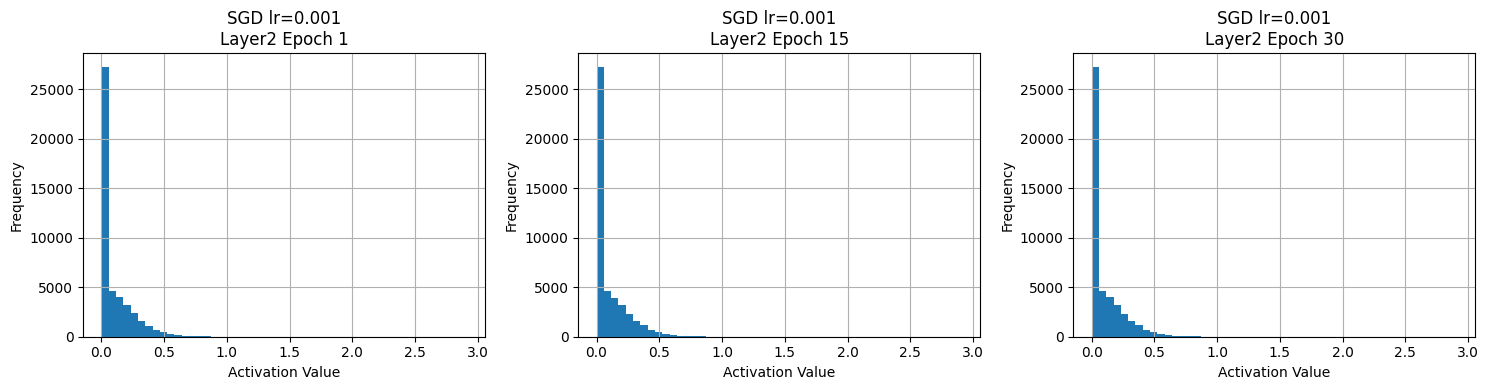

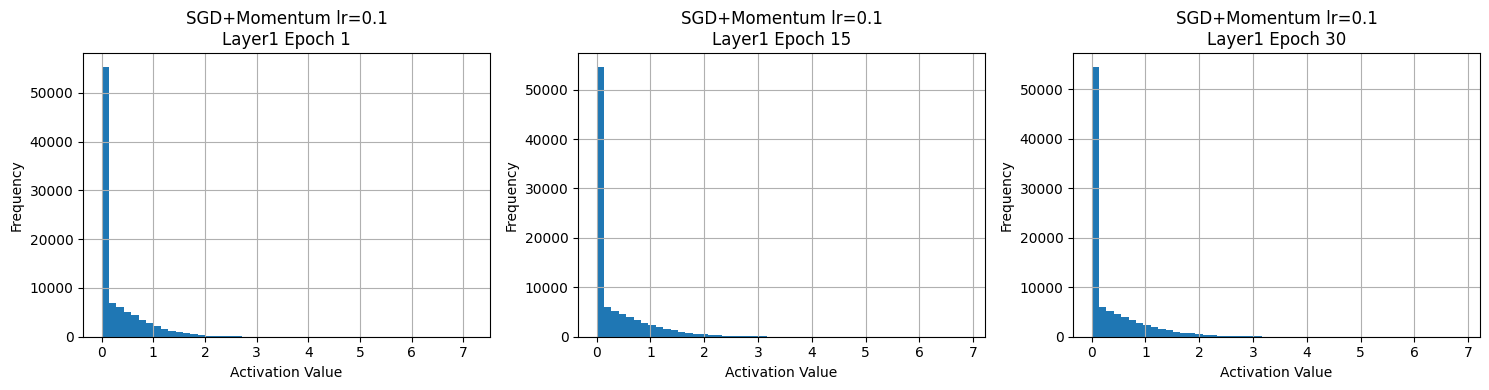

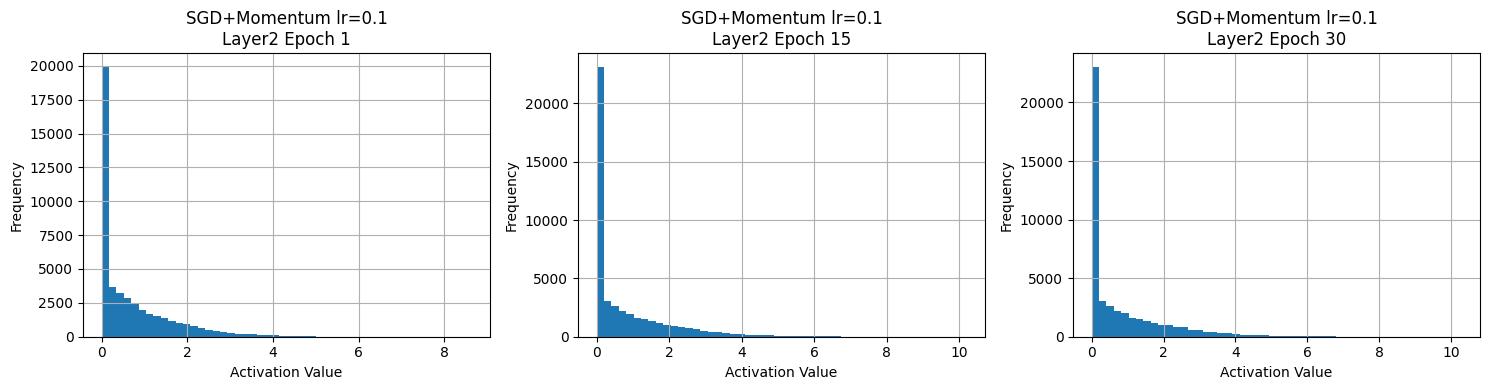

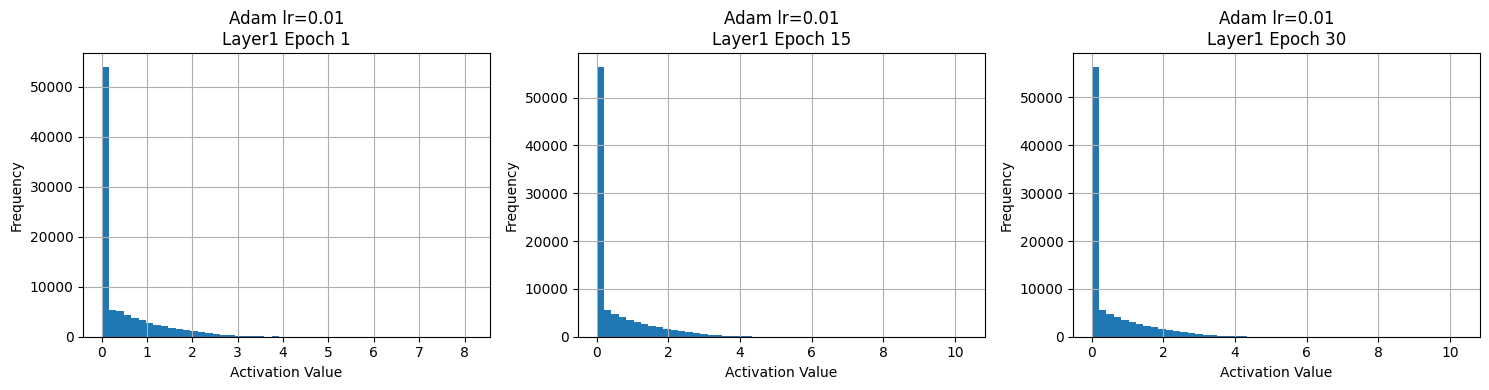

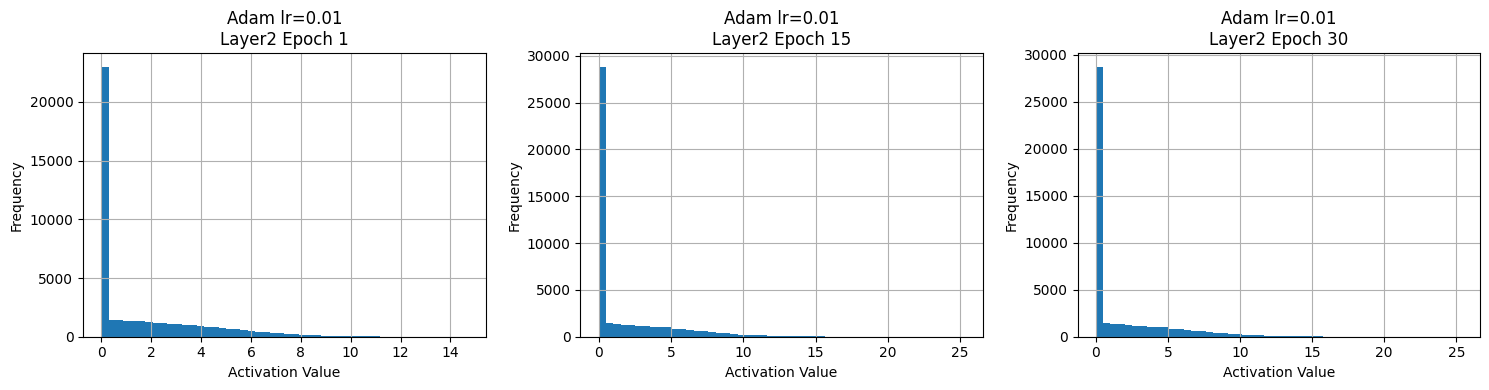

In [140]:
# 변화가 거의 없는 경우: SGD lr=0.001
sgd001_snapshots = visualize_experiment_c_activation(
    optimizer_type="sgd",
    lr=0.001,
    epochs=30
)

# 빠르게 수렴한 경우: SGD+Momentum lr=0.1
momentum01_snapshots = visualize_experiment_c_activation(
    optimizer_type="momentum",
    lr=0.1,
    epochs=30
)

# 빠르게 수렴한 경우: Adam lr=0.01
adam01_snapshots = visualize_experiment_c_activation(
    optimizer_type="adam",
    lr=0.01,
    epochs=30
)